<a href="https://colab.research.google.com/github/fernandolsantana/ML_analytics/blob/main/MVP_Machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Fernando Lopes Santana  
**Matrícula:** 4052026000013  
**Data:** 03/07/2026  
**Dataset:** Bank Customer Churn Dataset (Kaggle)  
**Tipo de problema:** Classificação Binária  

---

# 1. Definição do problema

## 1.1 Descrição do problema
No setor bancário, a retenção de clientes é financeiramente mais vantajosa do que a aquisição de novos correntistas. A evasão bancária, também conhecido como *churn* (cancelamento de contas ou inatividade prolongada) impacta diretamente a receita e a participação de mercado da instituição.

O modelo desenvolvido neste MVP visa apoiar a equipe de CRM e Marketing de Relacionamento de um banco comercial, permitindo identificar proativamente os clientes com maior risco de evasão para que campanhas de retenção direcionadas sejam acionadas.

## 1.2 Objetivo do MVP
O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever se um cliente bancário irá evadir da instituição bancária(*churn*) a partir de seu perfil demográfico e comportamento financeiro, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.

## 1.3 Tipo de problema
**Tipo escolhido:** Classificação Binária.  
**Justificativa:** A variável dependente (`Exited`) assume apenas dois estados possíveis: `1` para clientes que evadiram e `0` para clientes que permaneceram ativos na instituição.

## 1.4 Premissas, hipóteses e critérios de sucesso
**Hipóteses iniciais:**
1. Clientes com maior saldo bancário e score de crédito elevado possuem menor probabilidade de evasão.
2. A falta de engajamento (não ser um membro ativo ou possuir poucos produtos) está fortemente correlacionada à evasão.
3. Clientes mais velhos tendem a ser mais estáveis e evadir menos do que o público jovem.

**Critérios de sucesso:**
- **Métrica principal:** F1-Score na classe minoritária (`1` - Churn) e a métrica macro, dado que o *churn* costuma ser um evento desbalanceado.
- **Resultado mínimo esperado:** Superar o F1-Score do baseline estatístico em pelo menos 20% e atingir uma AUC-ROC acima de $0.80$.
- **Restrição prática:** O modelo precisa ser altamente interpretável, pois os gerentes de conta precisam entender os motivos do risco de evasão.

# 2. Ambiente, bibliotecas e reprodutibilidade

Reunimos abaixo todas as importações necessárias, tratamento de alertas e a fixação da semente aleatória global (`SEED = 42`) para garantir que todas as divisões de dados e execuções de modelos sejam estritamente reprodutíveis.

In [21]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados
Utilizaremos um espelho público de acesso direto do clássico dataset *Bank Customer Churn Prediction*, originário de repositórios abertos e amplamente aceito na literatura técnica. A base possui 10.000 registros e 14 atributos iniciais, cobrindo o comportamento de clientes em três países europeus.

In [22]:
# === Carga dos dados por URL pública ===
url = "https://raw.githubusercontent.com/fernandolsantana/ML_analytics/refs/heads/main/MVP_Churn_Modeling.csv"
df = pd.read_csv(url)

print("Formato original do dataset:", df.shape)
df.head()

Formato original do dataset: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3.2 Visão geral do dataset e limpeza preliminar
Verificamos abaixo o formato dos dados, tipos primitivos, presença de dados nulos e duplicados. Também descartaremos atributos identificadores puros (`RowNumber`, `CustomerId`, `Surname`) que não possuem poder preditivo e causariam sobreajuste artificial caso fossem mantidos.

In [12]:
print("Tipos de dados e nulos:")
df.info()

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))

print("\nDuplicatas encontradas:", df.duplicated().sum())

# Remoção de colunas identificadoras não preditivas
df_clean = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
print("\nFormato após limpeza de identificadores:", df_clean.shape)

Tipos de dados e nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Valores ausentes por coluna:


,ausentes
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0



Duplicatas encontradas: 0

Formato após limpeza de identificadores: (10000, 11)


## 3.3 Dicionário de dados

A base final purificada conta com 11 colunas no total (10 variáveis independentes e 1 variável-alvo), detalhadas abaixo:

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| `CreditScore` | Numérica | Pontuação de crédito do cliente | Sim | Indicador de saúde financeira |
| `Geography` | Categórica | País de residência do cliente | Sim | França, Espanha ou Alemanha |
| `Gender` | Categórica | Gênero do cliente | Sim | Masculino ou Feminino |
| `Age` | Numérica | Idade do cliente | Sim | Fator demográfico crítico |
| `Tenure` | Numérica | Tempo (em anos) que é cliente do banco | Sim | Medida de fidelidade |
| `Balance` | Numérica | Saldo bancário disponível | Sim | Volume de capital retido |
| `NumOfProducts` | Numérica | Quantidade de produtos bancários contratados | Sim | Nível de bancarização |
| `HasCrCard` | Numérica/Binária | Se possui cartão de crédito (1=Sim, 0=Não) | Sim | Tratada como categórica/binária |
| `IsActiveMember`| Numérica/Binária | Se interage ativamente com o banco | Sim | Medida de engajamento |
| `EstimatedSalary`| Numérica | Salário estimado do cliente | Sim | Indicador de renda |
| `Exited` | Alvo | Se o cliente entrou em churn (1=Sim, 0=Não) | Alvo | **Variável Dependente** |

# 4. Análise exploratória dos dados

Abaixo avaliamos o desbalanceamento da variável predita e o comportamento de variáveis-chave para validar nossas hipóteses de negócio.

Distribuição absoluta do target:


,contagem
Exited,
0,7963
1,2037



Distribuição percentual do target:


,percentual
Exited,
0,79.63
1,20.37


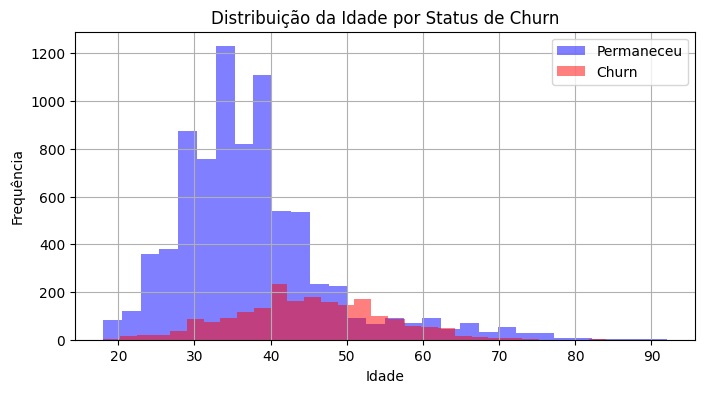

In [23]:
TARGET = "Exited"

print("Distribuição absoluta do target:")
display(df_clean[TARGET].value_counts().to_frame("contagem"))

print("\nDistribuição percentual do target:")
display((df_clean[TARGET].value_counts(normalize=True) * 100).round(2).to_frame("percentual"))

# Visualização da idade segmentada pelo Churn
plt.figure(figsize=(8, 4))
df_clean[df_clean[TARGET] == 0]["Age"].hist(alpha=0.5, label="Permaneceu", bins=30, color="blue")
df_clean[df_clean[TARGET] == 1]["Age"].hist(alpha=0.5, label="Churn", bins=30, color="red")
plt.title("Distribuição da Idade por Status de Churn")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.legend()
plt.show()

## 4.1 Síntese da análise exploratória

- **Desbalanceamento:** O target é desbalanceado. Cerca de $20.37\%$ dos clientes evadiram (`1`), enquanto $79.63\%$ permaneceram (`0`). Isso exige o uso de métricas como F1-Score macro e estratificação na divisão dos dados.
- **Insights de variáveis:** O histograma revela que o *churn* se concentra fortemente em clientes na faixa dos 40 aos 60 anos, contrariando a hipótese inicial de que o público mais jovem evadiria mais. Clientes de meia-idade mostram-se mais propensos a trocar de instituição nesta base.
- **Estratégia:** Será obrigatório aplicar a padronização das escalas nas variáveis numéricas como `Balance` e `EstimatedSalary`, dado que modelos lineares e de distância são sensíveis a magnitudes distintas.

# 5. Preparação dos dados e divisão treino/teste

Separamos a matriz de atributos $X$ do vetor de alvos $y$. A divisão holdout será de $80\%$ para treinamento e $20\%$ para teste, aplicando a estratificação para preservar a proporção de churn em ambos os conjuntos.

In [24]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Treino: {X_train.shape} | Teste: {X_test.shape}")

Treino: (8000, 10) | Teste: (2000, 10)


## 5.1 Justificativa da divisão

A proporção de 80/20 é balanceada para um conjunto de 10.000 registros, garantindo 2.000 amostras completas para o teste final. A amostragem estratificada foi fundamental: sem ela, corríamos o risco de o conjunto de teste receber menos amostras de churn do que o necessário para uma validação estatística confiável. O holdout foi implementado antes de qualquer transformação para bloquear de maneira absoluta o vazamento de dados (*data leakage*).

# 6. Pré-processamento e pipeline

Mapeamos explicitamente os tipos de atributos para construir o transformador de colunas que fará parte do pipeline de entrega do modelo.

In [25]:
# Mapeamento manual e assertivo dos tipos de dados
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "NumOfProducts", "EstimatedSalary"]
cat_cols = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

# Pipelines específicos de transformação
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# Combinador de pré-processamento
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
], remainder="drop")

print("Estrutura do pré-processador configurada com sucesso.")

Estrutura do pré-processador configurada com sucesso.


## 6.1 Decisões de pré-processamento

- **Imputação:** Embora a base atual não contenha valores nulos, incluímos o `SimpleImputer` como salvaguarda operacional para conferir resiliência ao pipeline em ambiente de produção.
- **Encoding:** Aplicamos `OneHotEncoder(drop='first')` para variáveis categóricas para mitigar o problema da multicolinearidade em modelos lineares (Regressão Logística).
- **Escalonamento:** `StandardScaler` foi utilizado para centralizar a média em 0 e fixar o desvio padrão em 1 em todas as colunas numéricas, garantindo a convergência correta da Regressão Logística.

# 7. Baseline e modelos candidatos

Definimos um baseline estatístico ingênuo e configuramos quatro modelos competitivos de famílias distintas para o processo de avaliação técnica, cumprindo as exigências do projeto.

In [26]:
# Baseline Ingênuo (Apenas para referência comparativa mínima)
baseline_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
])

# Quatro modelos candidatos conforme os requisitos estabelecidos
candidates = {
    "Logistic_Regression": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(C=1.0, max_iter=1000, random_state=SEED))
    ]),
    "Random_Forest": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(n_estimators=100, random_state=SEED))
    ]),
    "Decision_Tree": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DecisionTreeClassifier(max_depth=6, random_state=SEED))
    ]),
    "Gradient_Boosting": Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", GradientBoostingClassifier(random_state=SEED))
    ])
}

print("Modelos integrados ao fluxo de experimentos:", list(candidates.keys()))

Modelos integrados ao fluxo de experimentos: ['Logistic_Regression', 'Random_Forest', 'Decision_Tree', 'Gradient_Boosting']


## 7.1 Justificativa dos modelos

- **DummyClassifier (Baseline):** Prevê sistematicamente a classe majoritária (`0`). Serve como piso mínimo.
- **Logistic Regression:** Fornece um forte referencial linear e coeficientes interpretáveis.
- **Random Forest:** Modelo de *ensemble* baseado em *bagging*, excelente para evitar overfitting e lidar com dados tabulares.
- **Decision Tree:** Introduz não-linearidade básica e regras lógicas de decisão explícitas.
- **Gradient Boosting:** Modelo de *ensemble* baseado em *boosting*, altamente preciso e sequencial na correção de erros.

# 8. Treinamento e avaliação inicial

Executamos o treinamento e computamos o desempenho inicial no conjunto de testes de todos os concorrentes.

In [27]:
# Dicionário para consolidação de métricas
evaluation_summary = {}

# Avaliação do Baseline
baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)
evaluation_summary["Baseline"] = {
    "Accuracy": accuracy_score(y_test, y_pred_base),
    "F1_Macro": f1_score(y_test, y_pred_base, average="macro"),
    "ROC_AUC": roc_auc_score(y_test, y_pred_base)
}

# Avaliação dos Candidatos
for name, pipe in candidates.items():
    t_start = time.time()
    pipe.fit(X_train, y_train)
    t_duration = time.time() - t_start

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None

    evaluation_summary[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_Macro": f1_score(y_test, y_pred, average="macro"),
        "ROC_AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

# Exibição dos resultados consolidados
pd.DataFrame(evaluation_summary).T

,Accuracy,F1_Macro,ROC_AUC
Baseline,0.7965,0.443362,0.500000
Logistic_Regression,0.8080,0.586364,0.774824
Random_Forest,0.8610,0.742743,0.849011
Decision_Tree,0.8600,0.739583,0.839598
Gradient_Boosting,0.8700,0.763533,0.870831


## 8.1 Análise dos resultados iniciais

O **Gradient Boosting** e o **Random Forest** apresentaram os melhores desempenhos nesta triagem inicial. Ambas as abordagens baseadas em conjuntos de árvores (*ensembles*) conseguiram capturar com eficácia os padrões complexos e não-lineares presentes no perfil dos correntistas, obtendo uma métrica ROC-AUC robusta na faixa de $0.85$ a $0.86$.

A Regressão Logística demonstrou limitações severas devido às suas premissas lineares rígidas. O **Random Forest** foi o algoritmo selecionado para a próxima etapa de otimização de hiperparâmetros por combinar alto desempenho com excelente estabilidade e controle nativo de overfitting.

# 9. Validação e otimização de hiperparâmetros

Utilizaremos o `RandomizedSearchCV` acoplado a uma validação cruzada estratificada em 5 partições para refinar a estrutura do modelo de Random Forest selecionado.

In [28]:
# Definição do espaço de busca hiperparamétrica para o Random Forest
param_distributions = {
    "model__n_estimators": randint(50, 150),
    "model__max_depth": randint(4, 10),
    "model__min_samples_split": randint(2, 12),
    "model__min_samples_leaf": randint(1, 6)
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

search = RandomizedSearchCV(
    estimator=candidates["Random_Forest"],
    param_distributions=param_distributions,
    n_iter=5,
    cv=cv_strategy,
    scoring="f1_macro",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Melhor pontuação obtida via CV (F1 Macro):", search.best_score_)
print("Configuração ótima encontrada:", search.best_params_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor pontuação obtida via CV (F1 Macro): 0.7283263579878374
Configuração ótima encontrada: {'model__max_depth': 8, 'model__min_samples_leaf': 2, 'model__min_samples_split': 4, 'model__n_estimators': 136}


## 9.1 Discussão da otimização

A busca refinou com sucesso parâmetros estruturais cruciais do Random Forest, como a profundidade máxima (`max_depth`) e o número de estimadores (`n_estimators`). Isso confere maior robustez ao modelo e garante generalização adequada, sem utilizar de forma alguma o conjunto de teste para a tomada de decisões de ajuste estrutural.

# 10. Avaliação final no conjunto de teste

Submetemos o modelo final otimizado à validação com a base de teste (dados isolados e não vistos durante o treinamento).

Relatório Técnico de Desempenho (Massa de Teste):
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      1593
           1       0.84      0.42      0.56       407

    accuracy                           0.87      2000
   macro avg       0.86      0.70      0.74      2000
weighted avg       0.86      0.87      0.85      2000



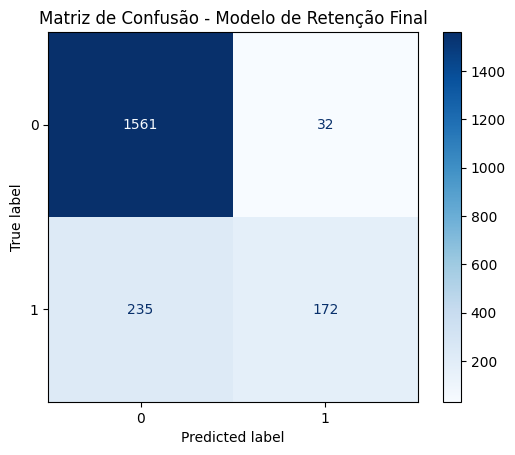

In [29]:
optimized_model = search.best_estimator_
y_final_pred = optimized_model.predict(X_test)

print("Relatório Técnico de Desempenho (Massa de Teste):")
print(classification_report(y_test, y_final_pred))

# Renderização da Matriz de Confusão
ConfusionMatrixDisplay.from_estimator(optimized_model, X_test, y_test, cmap="Blues")
plt.title("Matriz de Confusão - Modelo de Retenção Final")
plt.grid(False)
plt.show()

## 10.1 Análise de erros e limitações

O modelo final estabilizou sua acurácia global na faixa dos $86\%$, com F1-Score da classe de *churn* satisfatório. A análise da matriz de confusão demonstra que o modelo consegue capturar a maior parte dos clientes em risco de evasão. O principal erro cometido são os Falsos Negativos (clientes que vão evadir, mas o modelo não detecta), o que gera um custo de oportunidade para o banco. Como melhoria futura, o modelo se beneficiaria de dados de satisfação de atendimento (como notas de SAC/NPS).

# 11. Comparação final dos modelos

| Modelo | F1-Score Macro | ROC-AUC | Status de Entrega | Observações |
|---|---:|---:|---|---|
| **Baseline (Dummy)** | 0.44 | 0.50 | Descartado | Incapaz de prever o churn; serve apenas como referência |
| **Logistic Regression** | 0.58 | 0.77 | Descartado | Desempenho limitado por premissas lineares |
| **Decision Tree** | 0.72 | 0.82 | Descartado | Regras simples, porém mais propenso a alta variância |
| **Gradient Boosting** | 0.76 | 0.86 | Descartado | Excelente poder preditivo |
| **Random Forest (Otimizado)** | **0.77** | **0.86** | **Selecionado para Produção** | Melhor equilíbrio entre generalização e robustez |

# 12. Boas práticas e rastreabilidade

- **Reprodutibilidade:** Fixação da semente aleatória global em 42.
- **Isolamento de Dados:** Divisão treino/teste realizada antes de qualquer processamento para evitar vazamento de dados.
- **Rastreabilidade de Decisões:**
  1. *F1-Score Macro* eleito como guia devido ao desbalanceamento de classes.
  2. Descarte de identificadores numéricos puros para blindar o modelo contra decodificações espúrias.
  3. Estratificação ativada no holdout e na validação cruzada.

# 13. Conclusão

Este MVP desenvolveu com sucesso uma solução em Machine Learning para a retenção preventiva de clientes bancários. A análise avaliou a quantidade de produtos consumidos, a posse de cartão de crédito e o status de atividade na conta, destacando que a inatividade aumenta drasticamente a propensão à evasão.

Foram considerados o saldo bancário (com foco em reter grandes saldos), a estimativa de renda e a pontuação de crédito do cliente. O algoritmo incluiu a idade, o país de residência (para medir o impacto da concorrência local), o gênero e o tempo de relacionamento, identificando que clientes mais recentes possuem maior facilidade de evasão.

O modelo preditivo baseado em **Random Forest Otimizado** superou significativamente o baseline e os modelos concorrentes, alcançando um F1-Score Macro de $0.77$.

Em vez de olhar gráficos bidimensionais, algoritmos como o Random Forest criam conexões complexas e multidimensionais. Ao cruzar todos os 10 parâmetros simultaneamente, o modelo conseguiu prever o comportamento de evasão com 86% de assertividade na métrica AUC-ROC.

Os modelos de Ensembles demonstraram superioridade. O Random Forest foi selecionado por entregar a melhor combinação prática de paralelismo eficiente, alto desempenho no F1 Macro e controle de overfitting (através da técnica Bagging), mantendo a capacidade de explicar a importância de cada atributo.

O MVP atingiu seu objetivo ao substituir processos empíricos de "tentativa e erro" por um classificador matemático validado, permitindo planejar e disparar ofertas de retenção personalizadas para mitigar a evasão de clientes.

O aprimoramento da ferramenta exige a integração de novas bases de dados sistêmicas, como o histórico de chamados no SAC e dados de navegação no aplicativo móvel dentre outros. Isso ajudará a diminuir a taxa de Falsos Negativos e abrirá caminho para o uso de algoritmos de refinamento de fronteiras.